# LemoScan AI | Reproducible leakage-resistant split

**Manifest only. Six classes. No image copying, deletion, movement, renaming, model training, or application changes.**

This notebook enforces exact identity, existing A/B visual relationships, all saved SAME_SOURCE decisions, and additional relationships satisfying every strict autofill threshold. Ordinary C/D similarity and capture-sequence membership alone never merge groups. Transitive connected components are indivisible split units.

The result is leakage-resistant with respect to the **enforced evidence**, not proof of complete biological independence. Unreviewed candidate relationships remain a limitation and are reported separately. Historical model results do not transfer to this new split.

Run all cells with NumPy, Pandas, Pillow/Matplotlib's installed plotting environment, and IPython available. No packages are installed. Only new `reports/final_split/` artifacts are written. Existing decisions and evidence files are preserved.


## 1. Configuration and evidence integrity
Project root resolution supports a kernel started in the root or a child directory. All six input reports are loaded. All referenced files must exist, labels and hashes must agree, and image membership must match the inventory. The empty Not lemon leaf class is explicitly outside this split. The expected 2,050 images are verified, never used to invent counts.


In [1]:
from pathlib import Path
from collections import defaultdict
from datetime import datetime
import hashlib
import importlib.metadata as metadata
import json
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT_OVERRIDE = None
SEED = 42
SPLITS = ("train", "val", "test")
RATIOS = np.array([0.70, 0.15, 0.15])
CLASSES = sorted(["Algal leaf spot", "Black spot", "Citrus canker", "Citrus pest", "Greening", "Healthy leaf"])
EXPECTED_IMAGES = 2050
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff", ".gif"}
THRESHOLDS = {"phash_max": 2, "dhash_max": 2, "mae_max": 0.015, "color_min": 0.98, "number_gap_max": 1}
AUTO_NOTE = "Auto-prefilled from very strong multi-metric similarity; same class/capture sequence. Requires spot-check."


def resolve_root(override=None):
    roots = [Path(override).expanduser().resolve()] if override else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in roots:
        if (root / "dataset").is_dir() and (root / "utils/model_loader.py").is_file(): return root
    raise FileNotFoundError("Set PROJECT_ROOT_OVERRIDE to the LemoScan-AI project root.")


ROOT = resolve_root(PROJECT_ROOT_OVERRIDE)
DATASET = (ROOT / "dataset").resolve()
AUDIT = ROOT / "reports/dataset_audit"
OUTPUT = ROOT / "reports/final_split"
assert not OUTPUT.resolve().is_relative_to(DATASET)
INPUT_NAMES = ["grouping_manifest.csv", "manual_review_decisions.csv", "similarity_review.csv",
               "duplicate_clusters.csv", "refined_capture_sequence_review.csv", "image_inventory.csv"]
for name in INPUT_NAMES:
    if not (AUDIT / name).is_file(): raise FileNotFoundError(AUDIT / name)
inputs = {name: pd.read_csv(AUDIT / name, keep_default_na=False) for name in INPUT_NAMES}
prior_manifest = inputs["grouping_manifest.csv"]
decisions = inputs["manual_review_decisions.csv"]
similarity = inputs["similarity_review.csv"]
clusters = inputs["duplicate_clusters.csv"]
refined = inputs["refined_capture_sequence_review.csv"]
full_inventory = inputs["image_inventory.csv"]
inventory = full_inventory.loc[full_inventory["class"].isin(CLASSES)].sort_values("filepath").reset_index(drop=True)
assert len(inventory) == EXPECTED_IMAGES and inventory.filepath.is_unique
assert set(inventory["class"]) == set(CLASSES)
assert not full_inventory["class"].eq("Not lemon leaf").any(), "Negative-class images now exist; review this six-class-only scope."
assert set(full_inventory.filepath) == set(inventory.filepath), "Unexpected classes in inventory."
assert prior_manifest.filepath.is_unique and set(prior_manifest.filepath) == set(inventory.filepath)
assert decisions.pair_id.is_unique
assert set(decisions.human_decision) <= {"", "SAME_SOURCE", "DIFFERENT", "UNSURE"}
records = inventory.set_index("filepath").to_dict("index")


def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""): digest.update(chunk)
    return digest.hexdigest()


def dataset_snapshot():
    return {p.relative_to(ROOT).as_posix(): (p.stat().st_size, p.stat().st_mtime_ns, sha256_file(p))
            for p in sorted(DATASET.rglob("*")) if p.is_file()}


BEFORE = dataset_snapshot()
actual_images = {p for p in BEFORE if Path(p).suffix.lower() in EXTENSIONS}
assert actual_images == set(inventory.filepath), "Inventory no longer matches dataset membership."
for relative, row in records.items():
    absolute = (ROOT / relative).resolve()
    assert absolute.is_relative_to(DATASET) and absolute.is_file()
    assert BEFORE[relative][2] == row["sha256"], f"Stale hash: {relative}"
for frame, fields in [(prior_manifest, ["filepath"]), (clusters, ["filepath"]), (refined, ["filepath"]),
                      (decisions, ["filepath_a", "filepath_b"]), (similarity, ["filepath_a", "filepath_b"])]:
    for field in fields: assert set(frame[field]) <= set(records), f"Unknown reference in {field}"
for frame in (decisions, similarity):
    for row in frame.to_dict("records"):
        for side in ("a", "b"):
            original = records[row[f"filepath_{side}"]]
            for key in ("class", "split"):
                assert original[key] == row[f"{key}_{side}"], "Inconsistent evidence labels"
            if f"sha256_{side}" in row: assert original["sha256"] == row[f"sha256_{side}"]
for row in prior_manifest.to_dict("records"):
    assert row["sha256"] == records[row["filepath"]]["sha256"]
    assert row["class"] == records[row["filepath"]]["class"]
for row in clusters.to_dict("records"):
    assert row["sha256"] == records[row["filepath"]]["sha256"]
INPUT_HASHES = {name: sha256_file(AUDIT / name) for name in INPUT_NAMES}
print(f"Validated {len(inventory):,} six-class images. Not lemon leaf excluded.")
display(decisions.human_decision.replace("", "UNREVIEWED").value_counts().rename("saved_decisions").to_frame())


Validated 2,050 six-class images. Not lemon leaf excluded.


,saved_decisions
human_decision,
UNREVIEWED,517
SAME_SOURCE,10


## 2. Explicit grouping rules and evidence provenance
Mandatory grouping edges come from identical SHA-256, existing manifest A/B groups and duplicate clusters, all A/B pair evidence, and every SAME_SOURCE decision (human or autofilled). Additional strict links require same class, different old splits, valid matching date tokens, number gap <=1, pHash <=2, dHash <=2, MAE <=0.015, and color >=0.98. This matches the existing autofill rule, without assigning new human decisions.

Old split labels are consulted **only to identify existing cross-split evidence** and later for comparison, never as the split assignment target or balancing feature. Refined capture membership is context: only links already meeting A/B or strict rules are retained. Ordinary C/D, UNSURE, and filename proximity alone create no edge. DIFFERENT is not converted into a grouping edge; any conflict with mandatory connected evidence is surfaced and must be resolved rather than silently ignored.


In [2]:
def pair_key(first, second): return tuple(sorted((first, second)))


def pair_id(first, second):
    return "pair_" + hashlib.sha256(json.dumps(sorted([first, second]), ensure_ascii=False).encode("utf-8")).hexdigest()[:20]


def capture_tokens(relative):
    match = re.fullmatch(r"(\d{4}_\d{2}_\d{2})_IMG\s*\((\d+)\)", Path(relative).stem, flags=re.IGNORECASE)
    if not match: return None
    try: date = datetime.strptime(match[1], "%Y_%m_%d").date()
    except ValueError: return None
    return date, int(match[2])


def strict_match(row):
    if row["class_a"] != row["class_b"] or row["split_a"] == row["split_b"]: return False
    a, b = capture_tokens(row["filepath_a"]), capture_tokens(row["filepath_b"])
    if not a or not b or a[0] != b[0] or abs(a[1] - b[1]) > THRESHOLDS["number_gap_max"]: return False
    try:
        ph, dh, mae, color = [float(row[k]) for k in ["phash_distance", "dhash_distance", "normalized_pixel_mae", "color_histogram_intersection"]]
    except (ValueError, TypeError): return False
    return (all(math.isfinite(v) for v in (ph, dh, mae, color)) and ph.is_integer() and dh.is_integer()
            and 0 <= ph <= THRESHOLDS["phash_max"] and 0 <= dh <= THRESHOLDS["dhash_max"]
            and 0 <= mae <= THRESHOLDS["mae_max"] and THRESHOLDS["color_min"] <= color <= 1)


edge_reasons = defaultdict(set)

def add_edge(first, second, reason):
    if first != second: edge_reasons[pair_key(first, second)].add(reason)


def link_group(members, reason):
    members = sorted(members)
    for other in members[1:]: add_edge(members[0], other, reason)


for _, group in inventory.groupby("sha256", sort=True): link_group(group.filepath, "exact_sha256")
for _, group in prior_manifest.groupby("visual_group_id", sort=True): link_group(group.filepath, "existing_AB_manifest")
for _, group in clusters.groupby("cluster_id", sort=True): link_group(group.filepath, "existing_AB_cluster")
for row in decisions.loc[decisions.human_decision.eq("SAME_SOURCE")].to_dict("records"):
    reason = "autofilled_SAME_SOURCE" if row["review_notes"] == AUTO_NOTE else "human_SAME_SOURCE"
    add_edge(row["filepath_a"], row["filepath_b"], reason)
strict_pairs = []
for row in similarity.to_dict("records"):
    if row["category"] in ("A", "B"): add_edge(row["filepath_a"], row["filepath_b"], "AB_pair_evidence")
    if strict_match(row):
        add_edge(row["filepath_a"], row["filepath_b"], "strict_multimetric")
        strict_pairs.append(pair_key(row["filepath_a"], row["filepath_b"]))
refined_pair_ids = {p for value in refined.supporting_pair_ids for p in value.split("|") if p}
# Annotate qualifying refined links; do not merge whole refined sequences.
for (a, b), reasons in edge_reasons.items():
    if pair_id(a, b) in refined_pair_ids and ("AB_pair_evidence" in reasons or "strict_multimetric" in reasons):
        reasons.add("refined_capture_strong_link")
print(f"Mandatory/qualifying distinct grouping edges: {len(edge_reasons)}")
display(pd.Series({reason: sum(reason in values for values in edge_reasons.values())
                   for reason in sorted({r for values in edge_reasons.values() for r in values})}, name="edge_count").to_frame())


Mandatory/qualifying distinct grouping edges: 24


,edge_count
AB_pair_evidence,18
autofilled_SAME_SOURCE,4
exact_sha256,3
existing_AB_cluster,16
existing_AB_manifest,16
human_SAME_SOURCE,6
refined_capture_strong_link,8
strict_multimetric,4


## 3. Final connected source groups
A deterministic adjacency-list traversal merges strong chains transitively. IDs are SHA-256 hashes of sorted `(class, image SHA-256)` membership, including multiplicity, so old split names and file paths are absent from group identity. Group reasons are the union of enforced edge reasons; an unlinked image is a singleton.

Mixed-class source groups would require label adjudication; the notebook fails explicitly rather than separating related images or relabeling them. A saved DIFFERENT judgment conflicting with a mandatory connected group also stops execution. Neither condition is expected in the current reviewed evidence.


In [3]:
def components(nodes, edges):
    neighbors = {node: set() for node in nodes}
    for a, b in edges: neighbors[a].add(b); neighbors[b].add(a)
    seen, groups = set(), []
    for start in sorted(neighbors):
        if start in seen: continue
        stack, members = [start], []; seen.add(start)
        while stack:
            node = stack.pop(); members.append(node)
            for nxt in sorted(neighbors[node], reverse=True):
                if nxt not in seen: seen.add(nxt); stack.append(nxt)
        groups.append(sorted(members))
    return groups


source_components = components(records, edge_reasons)
path_group, group_rows, group_reasons = {}, [], {}
for members in source_components:
    labels = {records[p]["class"] for p in members}
    assert len(labels) == 1, f"Mixed-class related group requires review: {members}"
    content = sorted((records[p]["class"], records[p]["sha256"]) for p in members)
    group_id = "source_" + hashlib.sha256(json.dumps(content, separators=(",", ":")).encode("utf-8")).hexdigest()
    for path in members: path_group[path] = group_id
    group_rows.append({"source_group_id": group_id, "class": next(iter(labels)), "group_size": len(members)})
    group_reasons[group_id] = set()
for (a, b), reasons in edge_reasons.items():
    assert path_group[a] == path_group[b]
    group_reasons[path_group[a]].update(reasons)
for group_id in group_reasons:
    if not group_reasons[group_id]: group_reasons[group_id].add("singleton_no_enforced_relationship")
group_features = pd.DataFrame(group_rows).sort_values("source_group_id").reset_index(drop=True)
assert group_features.source_group_id.is_unique
for row in decisions.loc[decisions.human_decision.eq("DIFFERENT")].itertuples(index=False):
    assert path_group[row.filepath_a] != path_group[row.filepath_b], f"DIFFERENT conflicts with mandatory group: {row.pair_id}"
print(f"Final source groups: {len(group_features):,}; largest group: {group_features.group_size.max()} images")
display(group_features.groupby("class").agg(images=("group_size", "sum"), source_groups=("source_group_id", "size"), largest_group=("group_size", "max")))


Final source groups: 2,028; largest group: 4 images


,images,source_groups,largest_group
class,,,
Algal leaf spot,310,307,2
Black spot,330,326,2
Citrus canker,370,367,2
Citrus pest,390,388,2
Greening,350,349,2
Healthy leaf,300,291,4


## 4. Seeded group-aware stratification
The assignment function accepts **only content-derived source group ID, class, and group size**. It cannot inspect file paths, old split labels, existing model predictions, or historical accuracy.

1. Calculate global integer targets by largest remainder from 70/15/15. Allocate per-class integer quotas from floor counts, distributing remaining images by fractional remainder and global deficit, with seed-controlled ties.
2. Within each class, assign largest groups first; randomize equal-size order using a fresh local RNG with seed 42.
3. For each whole group, minimize quota overflow first, then normalized squared class-count deviation, with seeded tie-breaking.

This deterministic greedy allocation does not claim optimality for arbitrary datasets. Small related groups and many singletons permit close balance here. Assertions enforce all classes in every split, overall ratio error <=1 percentage point, and per-class count error no greater than that class's largest group. Old labels are added back only after assignment.


In [4]:
def integer_class_quotas(features, seed, ratios):
    rng = np.random.default_rng(seed)
    names = sorted(features["class"].unique())
    counts = features.groupby("class").group_size.sum().reindex(names).to_numpy(dtype=int)
    raw_global = counts.sum() * ratios
    global_targets = np.floor(raw_global + 1e-9).astype(int)
    extra = int(counts.sum() - global_targets.sum())
    order = sorted(range(len(ratios)), key=lambda j: (-(raw_global[j] - global_targets[j]), j))
    for j in order[:extra]: global_targets[j] += 1
    raw = counts[:, None] * ratios
    quotas = np.floor(raw + 1e-9).astype(int)
    deficits = global_targets - quotas.sum(axis=0)
    for i in rng.permutation(len(names)):
        remaining = int(counts[i] - quotas[i].sum())
        split_order = list(rng.permutation(len(ratios)))
        for _ in range(remaining):
            eligible = [j for j in range(len(ratios)) if deficits[j] > 0]
            j = min(eligible, key=lambda j: (-(raw[i, j] - quotas[i, j]), -deficits[j], split_order.index(j)))
            quotas[i, j] += 1; deficits[j] -= 1
    assert (deficits == 0).all() and np.array_equal(quotas.sum(axis=1), counts)
    return pd.DataFrame(quotas, index=names, columns=SPLITS), global_targets


def assign_source_groups(features, seed=SEED, ratios=RATIOS):
    if set(features.columns) != {"source_group_id", "class", "group_size"}:
        raise ValueError("Assignment accepts only group ID, class, and size; old split/path fields are forbidden.")
    features = features.sort_values("source_group_id").reset_index(drop=True)
    assert features.source_group_id.is_unique and features.group_size.gt(0).all()
    quotas, global_targets = integer_class_quotas(features, seed, ratios)
    rng = np.random.default_rng(seed)
    assignments = {}
    for name in sorted(features["class"].unique()):
        group = features.loc[features["class"].eq(name)].copy()
        group["seeded_tie_order"] = rng.permutation(len(group))
        group = group.sort_values(["group_size", "seeded_tie_order", "source_group_id"], ascending=[False, True, True])
        target = quotas.loc[name].to_numpy(dtype=int)
        actual = np.zeros(len(SPLITS), dtype=int)
        for row in group.itertuples(index=False):
            tie_order = list(rng.permutation(len(SPLITS)))
            def cost(j):
                proposed = actual.copy(); proposed[j] += row.group_size
                overflow = int(np.maximum(proposed - target, 0).sum())
                deviation = float(np.sum((proposed - target) ** 2 / np.maximum(target, 1)))
                return overflow, deviation, tie_order.index(j)
            chosen = min(range(len(SPLITS)), key=cost)
            assignments[row.source_group_id] = SPLITS[chosen]
            actual[chosen] += row.group_size
    return assignments, quotas, global_targets


assignment, target_class_counts, target_global_counts = assign_source_groups(group_features)
repeat, repeat_targets, _ = assign_source_groups(group_features.sample(frac=1, random_state=SEED + 1))
assert assignment == repeat and target_class_counts.equals(repeat_targets), "Seeded assignment is not reproducible."
# Explicitly demonstrate that forbidden old-split input is rejected.
try:
    assign_source_groups(group_features.assign(original_split="train"))
except ValueError:
    pass
else:
    raise AssertionError("Assignment unexpectedly accepted original split information.")
print("Integer class targets:")
display(target_class_counts)
print("Verified identical assignments after shuffling input rows; old split/path features rejected.")


Integer class targets:
Verified identical assignments after shuffling input rows; old split/path features rejected.


,train,val,test
Algal leaf spot,217,46,47
Black spot,231,50,49
Citrus canker,259,55,56
Citrus pest,273,59,58
Greening,245,53,52
Healthy leaf,210,45,45


## 5. Build the final manifest in memory
No image is copied or moved. `filepath` remains project-root-relative and points to the original image, regardless of its new assignment. Future InceptionV3 training must select rows by **new_split**, then load `PROJECT_ROOT / filepath`; never infer the new assignment from the old directory name. All image and label rows are retained, including duplicate bytes grouped into one split.


In [5]:
final_manifest = inventory[["filepath", "filename", "class", "split", "sha256"]].rename(columns={"split": "original_split"}).copy()
final_manifest["source_group_id"] = final_manifest.filepath.map(path_group)
final_manifest["new_split"] = final_manifest.source_group_id.map(assignment)
sizes = group_features.set_index("source_group_id").group_size
final_manifest["group_size"] = final_manifest.source_group_id.map(sizes)
final_manifest["group_reason"] = final_manifest.source_group_id.map({key: ";".join(sorted(value)) for key, value in group_reasons.items()})
FINAL_COLUMNS = ["filepath", "filename", "class", "original_split", "source_group_id", "new_split", "sha256", "group_size", "group_reason"]
final_manifest = final_manifest[FINAL_COLUMNS].sort_values("filepath").reset_index(drop=True)
assert len(final_manifest) == EXPECTED_IMAGES and final_manifest.filepath.is_unique
assert set(final_manifest.filepath) == set(inventory.filepath)
assert final_manifest.new_split.notna().all()
assert final_manifest.groupby("source_group_id").new_split.nunique().eq(1).all()
new_split_by_path = final_manifest.set_index("filepath").new_split.to_dict()
class_counts = pd.crosstab(final_manifest["class"], final_manifest.new_split).reindex(index=CLASSES, columns=SPLITS, fill_value=0)
split_counts = final_manifest.new_split.value_counts().reindex(SPLITS, fill_value=0)
class_percentages = class_counts.div(class_counts.sum(axis=1), axis=0).mul(100)
source_group_counts = final_manifest.groupby("new_split").source_group_id.nunique().reindex(SPLITS, fill_value=0)
assert class_counts.gt(0).all().all(), "Every class must appear in all splits."
assert np.max(np.abs(split_counts.to_numpy() / len(final_manifest) - RATIOS)) <= 0.01
for name in CLASSES:
    largest = group_features.loc[group_features["class"].eq(name), "group_size"].max()
    assert (class_counts.loc[name] - target_class_counts.loc[name]).abs().max() <= largest
print("Images and source groups per split:")
display(pd.DataFrame({"images": split_counts, "percentage": split_counts / len(final_manifest) * 100, "source_groups": source_group_counts}))
print("Class image counts:"); display(class_counts)
print("Percent of each class assigned to each split:"); display(class_percentages.round(3))
print("Largest source group:", int(final_manifest.group_size.max()))


Images and source groups per split:
Class image counts:
Percent of each class assigned to each split:
Largest source group: 4


,images,percentage,source_groups
new_split,,,
train,1435,70.00000,1419
val,308,15.02439,306
test,307,14.97561,303


new_split,train,val,test
class,,,
Algal leaf spot,217,46,47
Black spot,231,50,49
Citrus canker,259,55,56
Citrus pest,273,59,58
Greening,245,53,52
Healthy leaf,210,45,45


new_split,train,val,test
class,,,
Algal leaf spot,70.0,14.839,15.161
Black spot,70.0,15.152,14.848
Citrus canker,70.0,14.865,15.135
Citrus pest,70.0,15.128,14.872
Greening,70.0,15.143,14.857
Healthy leaf,70.0,15.000,15.000


## 6. Mandatory zero-leakage assertions
Each verification counts crossing groups or edges, as labeled. Overlapping evidence categories must not be added together. Exact SHA-256 groups, manifest visual IDs, duplicate-cluster IDs, A/B links, SAME_SOURCE decisions, strict autofill-qualified pairs, and final source groups must all remain within one new split.

The assertions certify these enforced constraints only. Unreviewed C/D pairs may still cross; they are reported as unresolved candidates rather than quietly treated as proof of duplication or independence.


In [6]:
def crossing_groups(frame, group_column):
    mapped = frame.assign(assigned_split=frame.filepath.map(new_split_by_path))
    assert mapped.assigned_split.notna().all()
    return int(mapped.groupby(group_column).assigned_split.nunique().gt(1).sum())


def crossing_edges(pairs):
    return sum(new_split_by_path[a] != new_split_by_path[b] for a, b in pairs)


same_source_pairs = list(decisions.loc[decisions.human_decision.eq("SAME_SOURCE"), ["filepath_a", "filepath_b"]].itertuples(index=False, name=None))
ab_pairs = list(similarity.loc[similarity.category.isin(["A", "B"]), ["filepath_a", "filepath_b"]].itertuples(index=False, name=None))
verification = {
    "source_groups_crossing_splits": crossing_groups(final_manifest, "source_group_id"),
    "exact_sha256_groups_crossing_splits": crossing_groups(inventory, "sha256"),
    "existing_visual_groups_crossing_splits": crossing_groups(prior_manifest, "visual_group_id"),
    "existing_AB_clusters_crossing_splits": crossing_groups(clusters, "cluster_id"),
    "AB_pair_edges_crossing_splits": crossing_edges(ab_pairs),
    "SAME_SOURCE_edges_crossing_splits": crossing_edges(same_source_pairs),
    "strict_multimetric_edges_crossing_splits": crossing_edges(strict_pairs),
    "all_enforced_edges_crossing_splits": crossing_edges(edge_reasons),
}
assert all(value == 0 for value in verification.values()), verification
assert len(final_manifest) == len(inventory) == EXPECTED_IMAGES
assert not final_manifest.filepath.duplicated().any()
assert set(final_manifest.filepath) == set(inventory.filepath)
for column in ("sha256", "class", "filename"):
    assert final_manifest.set_index("filepath")[column].sort_index().equals(inventory.set_index("filepath")[column].sort_index())
display(pd.Series(verification, name="cross_split_violations").to_frame())
print("All mandatory leakage assertions passed.")

# Record unresolved review candidates without expanding the mandatory graph.
decision_by_pair = {pair_key(row.filepath_a, row.filepath_b): row.human_decision for row in decisions.itertuples(index=False)}
unresolved = similarity.loc[similarity.category.isin(["C", "D"])].copy()
unresolved["saved_decision"] = [decision_by_pair.get(pair_key(a, b), "") for a, b in zip(unresolved.filepath_a, unresolved.filepath_b)]
unresolved["new_split_a"] = unresolved.filepath_a.map(new_split_by_path)
unresolved["new_split_b"] = unresolved.filepath_b.map(new_split_by_path)
unresolved = unresolved.loc[unresolved.saved_decision.isin(["", "UNSURE"]) & unresolved.new_split_a.ne(unresolved.new_split_b)]
print(f"Unresolved C/D candidate pairs still crossing the new split: {len(unresolved)} (not confirmed leakage).")


All mandatory leakage assertions passed.
Unresolved C/D candidate pairs still crossing the new split: 410 (not confirmed leakage).


,cross_split_violations
source_groups_crossing_splits,0
exact_sha256_groups_crossing_splits,0
existing_visual_groups_crossing_splits,0
existing_AB_clusters_crossing_splits,0
AB_pair_edges_crossing_splits,0
SAME_SOURCE_edges_crossing_splits,0
strict_multimetric_edges_crossing_splits,0
all_enforced_edges_crossing_splits,0


## 7. New distribution and before/after comparison
Matplotlib only. Old labels enter these descriptive charts after the final assignment is fixed. Similar before/after counts do not mean identical membership: the transition table records old-to-new image assignments. The dataset folders themselves remain unchanged.


Original folder assignment (rows) to new manifest assignment (columns):


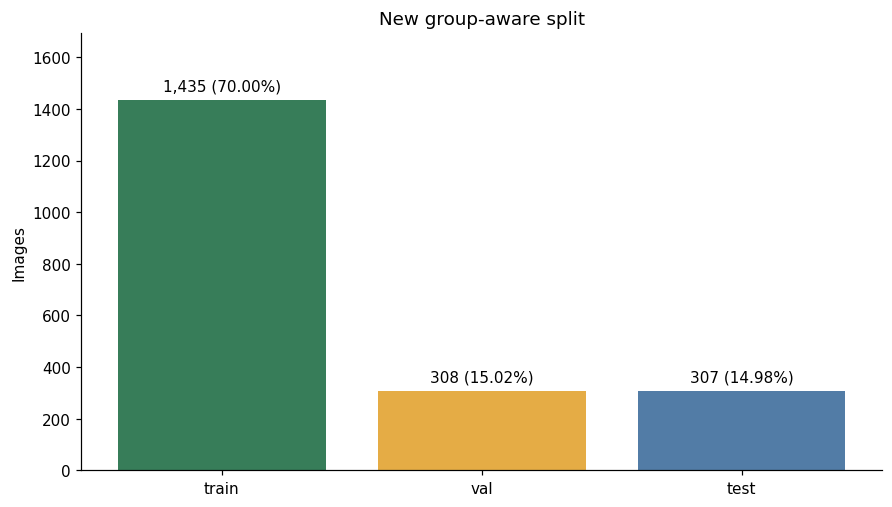

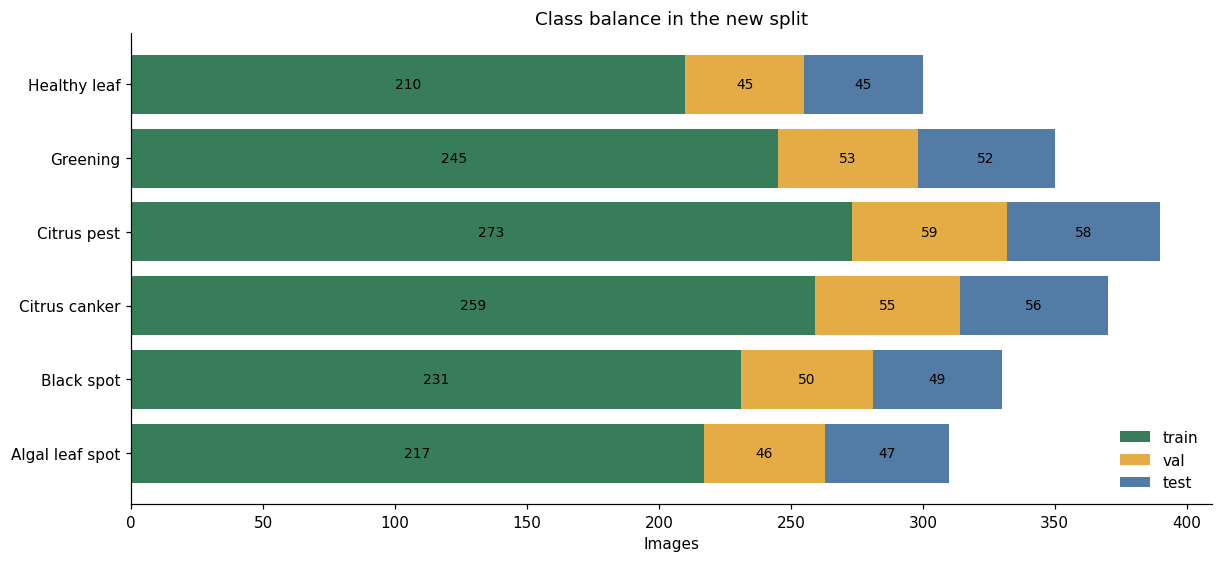

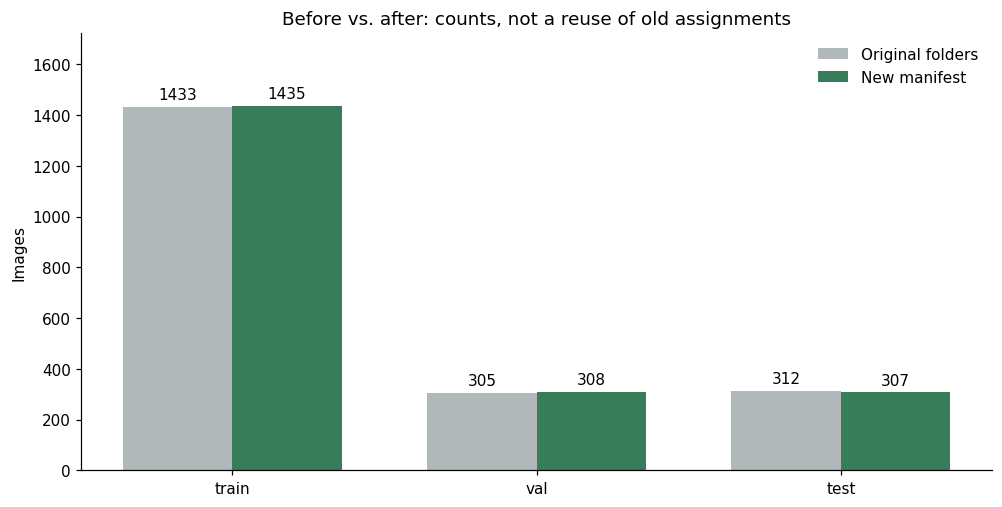

new_split,train,val,test
original_split,,,
train,1006,208,219
val,204,49,52
test,225,51,36


In [7]:
OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES = OUTPUT / "figures"
FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
COLORS = ["#377d59", "#e5ac45", "#527ca6"]
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
bars = ax.bar(SPLITS, split_counts.values, color=COLORS)
ax.bar_label(bars, labels=[f"{count:,} ({count / len(final_manifest):.2%})" for count in split_counts], padding=4)
ax.set(title="New group-aware split", ylabel="Images")
ax.margins(y=0.18)
fig.savefig(FIGURES / "new_split_sizes.png", dpi=140, bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
left = np.zeros(len(CLASSES))
for split, color in zip(SPLITS, COLORS):
    values = class_counts[split].to_numpy()
    bars = ax.barh(CLASSES, values, left=left, label=split, color=color)
    ax.bar_label(bars, label_type="center", fontsize=9)
    left += values
ax.set(title="Class balance in the new split", xlabel="Images")
ax.legend(frameon=False, loc="lower right")
fig.savefig(FIGURES / "class_distribution_by_split.png", dpi=140, bbox_inches="tight")
plt.show()
original_counts = final_manifest.original_split.value_counts().reindex(SPLITS, fill_value=0)
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
x = np.arange(len(SPLITS))
for offset, values, label, color in [(-0.18, original_counts.values, "Original folders", "#b0b8ba"),
                                    (0.18, split_counts.values, "New manifest", "#377d59")]:
    bars = ax.bar(x + offset, values, width=0.36, label=label, color=color)
    ax.bar_label(bars, padding=3)
ax.set(xticks=x, xticklabels=SPLITS, ylabel="Images", title="Before vs. after: counts, not a reuse of old assignments")
ax.margins(y=0.20); ax.legend(frameon=False)
fig.savefig(FIGURES / "before_after_split_counts.png", dpi=140, bbox_inches="tight")
plt.show()
transition = pd.crosstab(final_manifest.original_split, final_manifest.new_split).reindex(index=SPLITS, columns=SPLITS, fill_value=0)
print("Original folder assignment (rows) to new manifest assignment (columns):")
display(transition)


## 8. Export the verified manifest and reproducibility record
Only the new final-split report directory is written. Source paths and labels, all prior reports, and every dataset file are verified unchanged. The JSON records the seed, target/actual distributions, grouping provenance, hashes of input reports, a manifest checksum, reproducibility checks, and unresolved candidate counts. Re-running on unchanged evidence and seed yields the same manifest bytes; changing human decisions intentionally creates a new grouping result.


In [8]:
assert BEFORE == dataset_snapshot(), "Dataset content, names, membership, size, or modification times changed."
assert INPUT_HASHES == {name: sha256_file(AUDIT / name) for name in INPUT_NAMES}, "Prior evidence or decisions changed during execution."
replayed = final_manifest.copy()
replayed["new_split"] = replayed.source_group_id.map(repeat)
manifest_bytes = final_manifest.to_csv(index=False, lineterminator="\n").encode("utf-8")
assert manifest_bytes == replayed.to_csv(index=False, lineterminator="\n").encode("utf-8")
(OUTPUT / "final_split_manifest.csv").write_bytes(manifest_bytes)
class_counts.to_csv(OUTPUT / "class_split_counts.csv")
class_percentages.to_csv(OUTPUT / "class_split_percentages.csv", float_format="%.6f")
transition.to_csv(OUTPUT / "before_after_transition_counts.csv")
group_export = group_features.copy()
group_export["new_split"] = group_export.source_group_id.map(assignment)
group_export["group_reason"] = group_export.source_group_id.map({key: ";".join(sorted(value)) for key, value in group_reasons.items()})
group_export.to_csv(OUTPUT / "source_groups.csv", index=False)
edges_export = pd.DataFrame([{"filepath_a": a, "filepath_b": b, "source_group_id": path_group[a],
                              "group_reason": ";".join(sorted(reasons))}
                             for (a, b), reasons in sorted(edge_reasons.items())],
                            columns=["filepath_a", "filepath_b", "source_group_id", "group_reason"])
edges_export.to_csv(OUTPUT / "enforced_grouping_edges.csv", index=False)
unresolved.to_csv(OUTPUT / "unresolved_CD_cross_split_candidates.csv", index=False)
same_source = decisions.loc[decisions.human_decision.eq("SAME_SOURCE")]
summary = {
    "schema_version": 1, "seed": SEED,
    "target_ratios": dict(zip(SPLITS, RATIOS.tolist())),
    "target_integer_counts": {split: int(value) for split, value in zip(SPLITS, target_global_counts)},
    "actual_ratios": {split: float(split_counts[split] / len(final_manifest)) for split in SPLITS},
    "actual_counts": {split: int(split_counts[split]) for split in SPLITS},
    "class_counts": {name: {split: int(class_counts.loc[name, split]) for split in SPLITS} for name in CLASSES},
    "class_percentages": {name: {split: float(class_percentages.loc[name, split]) for split in SPLITS} for name in CLASSES},
    "total_images": len(final_manifest), "total_source_groups": len(group_features),
    "source_group_counts_by_split": {split: int(source_group_counts[split]) for split in SPLITS},
    "largest_group_size": int(group_features.group_size.max()),
    "non_singleton_source_groups": int(group_features.group_size.gt(1).sum()),
    "excluded_classes": ["Not lemon leaf"],
    "enforced_grouping_edges": len(edge_reasons),
    "group_reason_edge_counts": {reason: sum(reason in reasons for reasons in edge_reasons.values())
                                 for reason in sorted({r for reasons in edge_reasons.values() for r in reasons})},
    "SAME_SOURCE_decisions_enforced": len(same_source),
    "autofilled_SAME_SOURCE_decisions_enforced": int(same_source.review_notes.eq(AUTO_NOTE).sum()),
    "refined_capture_sequences_loaded": int(refined.refined_capture_group_id.nunique()),
    "capture_policy": "Refined sequence membership alone does not merge images; only qualifying A/B or strict edges are annotated.",
    "strict_multimetric_thresholds": THRESHOLDS,
    "strict_multimetric_additional_conditions": "Same class, cross-split evidence, matching valid filename date, number gap <=1; all metrics required.",
    "leakage_verification": verification, "all_mandatory_leakage_assertions_passed": True,
    "unresolved_CD_pairs_crossing_new_split": len(unresolved),
    "unresolved_CD_pairs_by_category": {str(k): int(v) for k, v in unresolved.category.value_counts().sort_index().items()},
    "reproducibility": {"seeded_replay_identical": True, "input_row_order_invariant": True,
                        "original_split_features_rejected": True,
                        "assignment_input_columns": sorted(group_features.columns)},
    "dataset_unchanged": True, "existing_evidence_and_decisions_unchanged": True,
    "input_report_sha256": INPUT_HASHES,
    "manifest_sha256": hashlib.sha256(manifest_bytes).hexdigest(),
    "environment": {name: metadata.version(name) for name in ["numpy", "pandas", "matplotlib"]},
    "interpretation": "Leakage checks certify enforced exact, A/B, SAME_SOURCE, and strict relationships only. Unreviewed C/D or unknown shared specimens may remain. No image operations, training, or application changes were performed."
}
(OUTPUT / "split_summary.json").write_text(json.dumps(summary, indent=2, sort_keys=True) + "\n", encoding="utf-8")
assert sha256_file(OUTPUT / "final_split_manifest.csv") == summary["manifest_sha256"]
print("Saved:", OUTPUT / "final_split_manifest.csv")
print("Saved:", OUTPUT / "split_summary.json")
print("Read-only dataset verification passed; existing decisions/evidence preserved.")


Saved: E:\LemoScan-AI\reports\final_split\final_split_manifest.csv
Saved: E:\LemoScan-AI\reports\final_split\split_summary.json
Read-only dataset verification passed; existing decisions/evidence preserved.


## 9. Interpretation and next training step
The manifest is ready for the next six-class InceptionV3 training notebook. Resolve each filepath against the project root and filter by new_split. Fit any learned preprocessing on training rows only, select models using validation only, and keep test outcomes out of model-selection decisions.

Ordinary C/D candidates were deliberately not automatically merged. A passing strong-evidence audit does not establish independence for those unresolved relationships, all acquisition sessions, or biological specimens. This is a documented conservative grouping policy, not a claim of a perfectly independent research benchmark. No model is trained here.


In [9]:
display(Markdown(f"""
**Verified split:** {split_counts['train']:,} train / {split_counts['val']:,} validation / {split_counts['test']:,} test images.

**Groups:** {len(group_features):,} indivisible source groups; largest {int(group_features.group_size.max())} images. All six classes appear in all three splits. All {len(verification)} mandatory leakage checks returned zero.

**Reproducibility:** seed {SEED}; replay and shuffled-input checks produced identical manifest bytes. Dataset files and saved decisions are unchanged.

**Remaining limitation:** {len(unresolved)} unresolved C/D candidate pairs cross the new assignment. These are not confirmed leakage, but independence beyond the enforced relationships has not been established. The residual-candidate CSV preserves this limitation for reporting.
"""))



**Verified split:** 1,435 train / 308 validation / 307 test images.

**Groups:** 2,028 indivisible source groups; largest 4 images. All six classes appear in all three splits. All 8 mandatory leakage checks returned zero.

**Reproducibility:** seed 42; replay and shuffled-input checks produced identical manifest bytes. Dataset files and saved decisions are unchanged.

**Remaining limitation:** 410 unresolved C/D candidate pairs cross the new assignment. These are not confirmed leakage, but independence beyond the enforced relationships has not been established. The residual-candidate CSV preserves this limitation for reporting.
